<a href="https://colab.research.google.com/github/Jayantsinghkhanna/UCS547-ACCELERATED-DATA-SCIENCE-LAB/blob/main/Assignment_4_Accelerated_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numba numpy matplotlib

In [2]:
# ============================================================
#  Q1: f(x) = x² + 3x + 5  |  CPU vs GPU  |  float32 & float64
#  Runtime: Colab T4 GPU
# ============================================================

import numpy as np
import numba
from numba import cuda
import time

print("Numba:", numba.__version__)
print("CUDA available:", cuda.is_available())

N = 5_000_000

# ─────────────────────────────────────────
#  CUDA KERNELS
# ─────────────────────────────────────────

@cuda.jit
def kernel_f32(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        xi     = x[i]
        out[i] = xi * xi + 3.0 * xi + 5.0

@cuda.jit
def kernel_f64(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        xi     = x[i]
        out[i] = xi * xi + 3.0 * xi + 5.0

# ─────────────────────────────────────────
#  CPU (NumPy)
# ─────────────────────────────────────────

arr_cpu = np.random.rand(N).astype(np.float64)

t0      = time.perf_counter()
out_cpu = arr_cpu**2 + 3*arr_cpu + 5
cpu_time = time.perf_counter() - t0

print(f"\n[CPU]  float64 → {cpu_time*1000:.2f} ms")

# ─────────────────────────────────────────
#  GPU HELPER
# ─────────────────────────────────────────

THREADS = 256

def run_gpu(kernel, dtype, label):
    arr = np.random.rand(N).astype(dtype)
    out = np.zeros(N, dtype=dtype)

    d_arr = cuda.to_device(arr)
    d_out = cuda.to_device(out)
    blocks = (N + THREADS - 1) // THREADS

    # warm-up (triggers JIT compile)
    kernel[blocks, THREADS](d_arr, d_out)
    cuda.synchronize()

    # timed run
    t0 = time.perf_counter()
    kernel[blocks, THREADS](d_arr, d_out)
    cuda.synchronize()
    elapsed = time.perf_counter() - t0

    result = d_out.copy_to_host()
    print(f"[GPU]  {label} → {elapsed*1000:.4f} ms  |  Speedup: {cpu_time/elapsed:.1f}x")
    return result, arr

# ─────────────────────────────────────────
#  RUN GPU (float32 & float64)
# ─────────────────────────────────────────

out_f32, arr_f32 = run_gpu(kernel_f32, np.float32, "float32")
out_f64, arr_f64 = run_gpu(kernel_f64, np.float64, "float64")

# ─────────────────────────────────────────
#  CORRECTNESS CHECK
# ─────────────────────────────────────────

ref_f32 = arr_f32.astype(np.float64)**2 + 3*arr_f32.astype(np.float64) + 5
ref_f64 = arr_f64**2 + 3*arr_f64 + 5

print(f"\nCorrectness f32 (rtol=1e-4): {np.allclose(out_f32, ref_f32.astype(np.float32), rtol=1e-4)}")
print(f"Correctness f64 (allclose) : {np.allclose(out_f64, ref_f64)}")

# ─────────────────────────────────────────
#  SAMPLE OUTPUT
# ─────────────────────────────────────────

print(f"\nFirst 3 values (f64 GPU): {out_f64[:3]}")
print(f"First 3 values (CPU ref): {ref_f64[:3]}")

Numba: 0.60.0
CUDA available: True

[CPU]  float64 → 31.91 ms
[GPU]  float32 → 0.7170 ms  |  Speedup: 44.5x
[GPU]  float64 → 0.4616 ms  |  Speedup: 69.1x

Correctness f32 (rtol=1e-4): True
Correctness f64 (allclose) : True

First 3 values (f64 GPU): [6.32900754 7.27297924 6.7022048 ]
First 3 values (CPU ref): [6.32900754 7.27297924 6.7022048 ]


Numba: 0.60.0

[Pure Python]  925.0 ms   | total=1000000
[NumPy]        68.16 ms  | total=1000000  | speedup vs Python: 13.6x
[Numba serial] 4.91 ms  | total=1000000  | speedup vs Python: 188.4x  | speedup vs NumPy: 13.88x
[Numba parallel]3.06 ms  | total=998686  | speedup vs Python: 302.7x  | speedup vs NumPy: 22.31x

── Correctness ──────────────────────────────────────
Python  total  : 1000000   (expected 1000000)
NumPy   total  : 1000000
Numba S total  : 1000000
Numba P total  : 998686

Numba serial  matches NumPy: True
Numba parallel matches NumPy: False
Max bin diff (serial  vs NumPy): 0
Max bin diff (parallel vs NumPy): 9


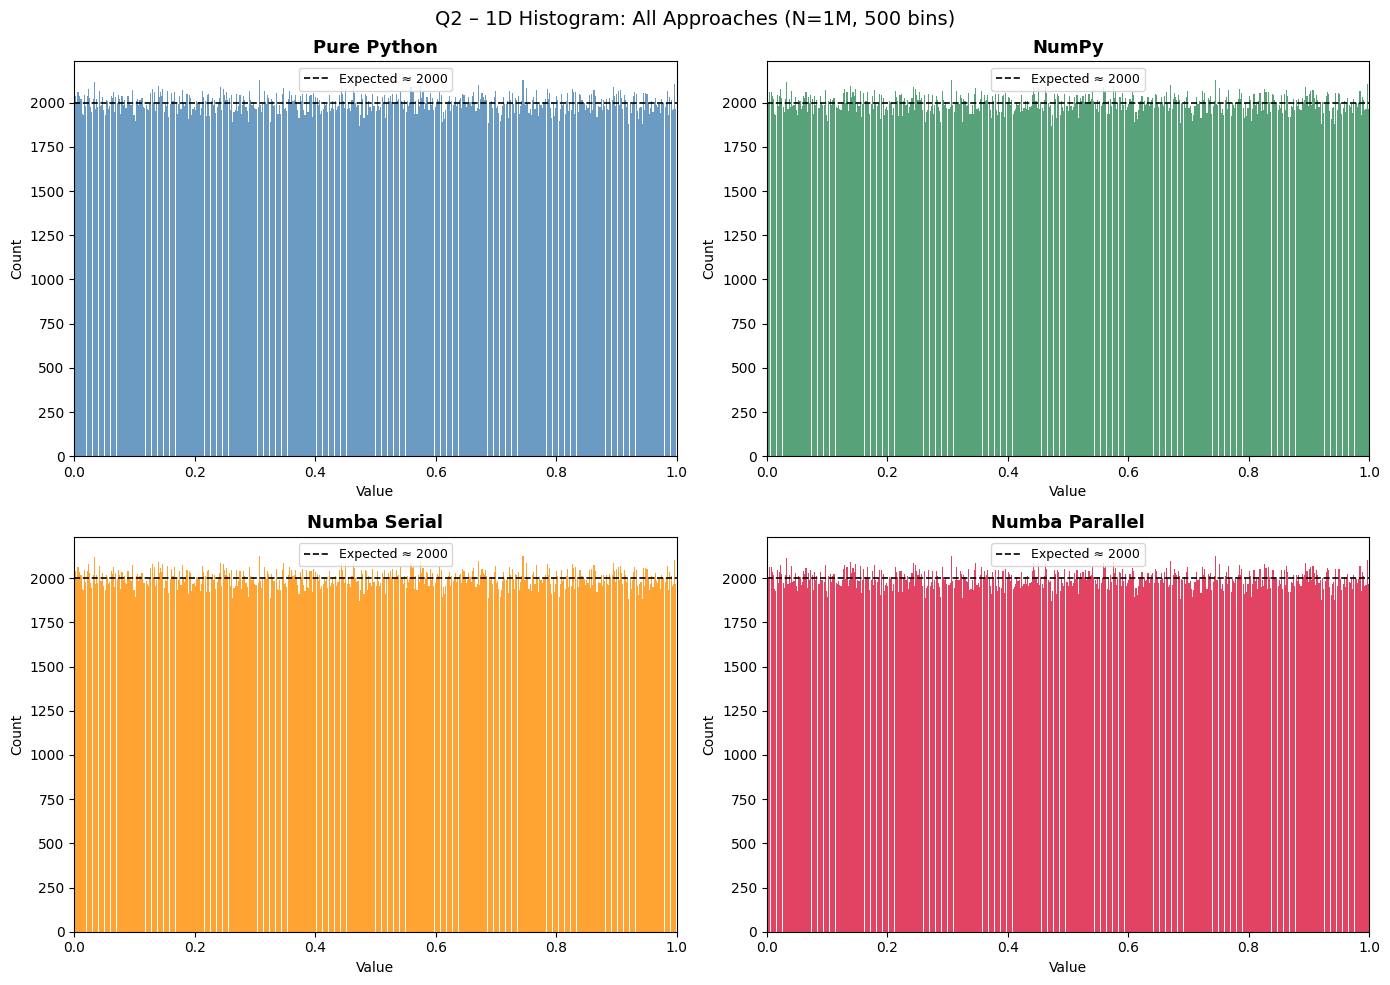

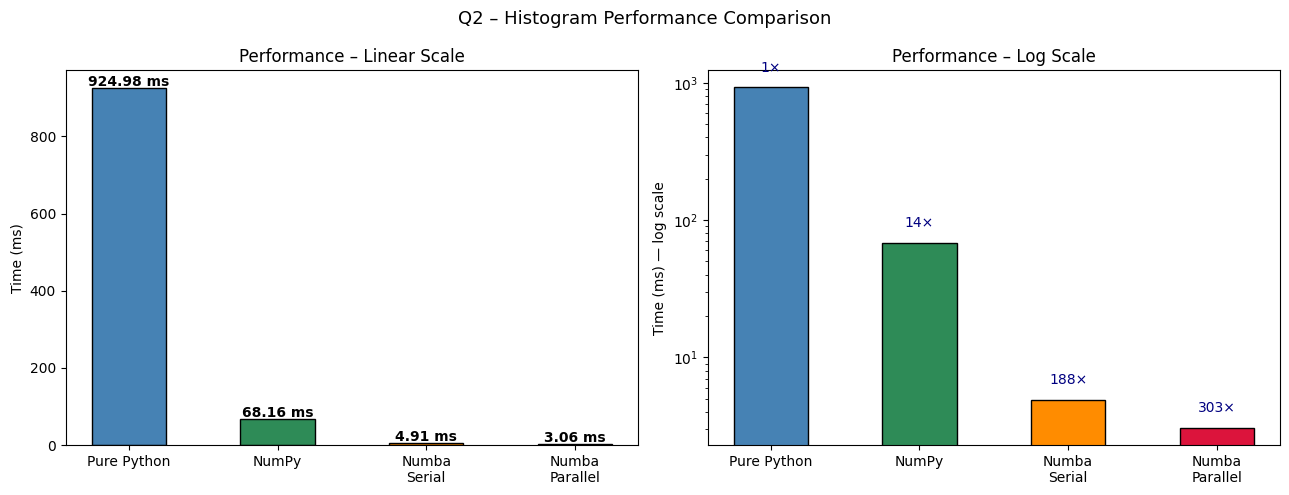


Method              Time (ms)  vs Python   vs NumPy
Pure Python            924.98       1.0x      0.07x
NumPy                   68.16      13.6x      1.00x
Numba Serial             4.91     188.4x     13.88x
Numba Parallel           3.06     302.7x     22.31x


In [3]:
# ============================================================
#  Q2: 1-D Histogram — Pure Python vs NumPy vs Numba
#  1 Million random values, 500 bins
#  Colab-ready (CPU runtime is fine)
# ============================================================

import numpy as np
import numba
from numba import njit, prange
import time
import matplotlib.pyplot as plt

print("Numba:", numba.__version__)

N    = 1_000_000
BINS = 500
data = np.random.uniform(0.0, 1.0, N).astype(np.float64)

# ─────────────────────────────────────────
#  APPROACH 1 — Pure Python
# ─────────────────────────────────────────

def python_histogram(data, n_bins):
    min_val = min(data)
    max_val = max(data)
    bin_width = (max_val - min_val) / n_bins
    counts = [0] * n_bins

    for x in data:
        idx = int((x - min_val) / bin_width)
        if idx >= n_bins:        # clamp exactly-max values
            idx = n_bins - 1
        counts[idx] += 1

    return counts, min_val, bin_width

t0 = time.perf_counter()
py_counts, py_min, py_bw = python_histogram(data.tolist(), BINS)
py_time = time.perf_counter() - t0
print(f"\n[Pure Python]  {py_time*1000:.1f} ms   | total={sum(py_counts)}")

# ─────────────────────────────────────────
#  APPROACH 2 — NumPy
# ─────────────────────────────────────────

t0 = time.perf_counter()
np_counts, bin_edges = np.histogram(data, bins=BINS)
np_time = time.perf_counter() - t0
print(f"[NumPy]        {np_time*1000:.2f} ms  | total={np_counts.sum()}"
      f"  | speedup vs Python: {py_time/np_time:.1f}x")

# ─────────────────────────────────────────
#  APPROACH 3a — Numba (serial)
# ─────────────────────────────────────────

@njit
def numba_histogram_serial(data, n_bins):
    min_val   = data.min()
    max_val   = data.max()
    bin_width = (max_val - min_val) / n_bins
    counts    = np.zeros(n_bins, dtype=np.int64)

    for i in range(len(data)):
        idx = int((data[i] - min_val) / bin_width)
        if idx >= n_bins:
            idx = n_bins - 1
        counts[idx] += 1

    return counts, min_val, bin_width

# warm-up / compile
_ = numba_histogram_serial(data[:100], BINS)

t0 = time.perf_counter()
nb_counts_s, nb_min_s, nb_bw_s = numba_histogram_serial(data, BINS)
nb_serial_time = time.perf_counter() - t0
print(f"[Numba serial] {nb_serial_time*1000:.2f} ms  | total={nb_counts_s.sum()}"
      f"  | speedup vs Python: {py_time/nb_serial_time:.1f}x"
      f"  | speedup vs NumPy: {np_time/nb_serial_time:.2f}x")

# ─────────────────────────────────────────
#  APPROACH 3b — Numba (parallel, prange)
# ─────────────────────────────────────────

@njit(parallel=True)
def numba_histogram_parallel(data, n_bins):
    """
    Each thread gets a private counts array.
    Final reduction sums all private arrays → avoids race conditions.
    """
    min_val   = data.min()
    max_val   = data.max()
    bin_width = (max_val - min_val) / n_bins

    # Thread-local storage: shape (n_threads, n_bins) — Numba handles split
    counts = np.zeros(n_bins, dtype=np.int64)

    for i in prange(len(data)):          # prange → parallel loop
        idx = int((data[i] - min_val) / bin_width)
        if idx >= n_bins:
            idx = n_bins - 1
        counts[idx] += 1                 # Numba handles thread-safe reduction

    return counts, min_val, bin_width

# warm-up / compile
_ = numba_histogram_parallel(data[:100], BINS)

t0 = time.perf_counter()
nb_counts_p, nb_min_p, nb_bw_p = numba_histogram_parallel(data, BINS)
nb_parallel_time = time.perf_counter() - t0
print(f"[Numba parallel]{nb_parallel_time*1000:.2f} ms  | total={nb_counts_p.sum()}"
      f"  | speedup vs Python: {py_time/nb_parallel_time:.1f}x"
      f"  | speedup vs NumPy: {np_time/nb_parallel_time:.2f}x")

# ─────────────────────────────────────────
#  CORRECTNESS CHECK
# ─────────────────────────────────────────

print("\n── Correctness ──────────────────────────────────────")
print(f"Python  total  : {sum(py_counts)}   (expected {N})")
print(f"NumPy   total  : {np_counts.sum()}")
print(f"Numba S total  : {nb_counts_s.sum()}")
print(f"Numba P total  : {nb_counts_p.sum()}")

# Reconstruct bin centres from NumPy edges for comparison baseline
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Align Python/Numba counts to NumPy bins (same bin width, same range)
print(f"\nNumba serial  matches NumPy: {np.array_equal(nb_counts_s, np_counts)}")
print(f"Numba parallel matches NumPy: {np.array_equal(nb_counts_p, np_counts)}")

# Max absolute bin difference
print(f"Max bin diff (serial  vs NumPy): {np.max(np.abs(nb_counts_s - np_counts))}")
print(f"Max bin diff (parallel vs NumPy): {np.max(np.abs(nb_counts_p - np_counts))}")

# ─────────────────────────────────────────
#  VISUALISATION 1 — Histogram overlays
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (py_counts,    'Pure Python', 'steelblue'),
    (np_counts,    'NumPy',       'seagreen'),
    (nb_counts_s,  'Numba Serial','darkorange'),
    (nb_counts_p,  'Numba Parallel','crimson'),
]

for ax, (counts, title, color) in zip(axes.flat, configs):
    bw  = 1.0 / BINS
    centres = np.linspace(bw/2, 1 - bw/2, BINS)
    ax.bar(centres, counts, width=bw*0.9, color=color, alpha=0.8)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.set_xlim(0, 1)
    # Expected count line
    ax.axhline(N / BINS, color='black', ls='--', lw=1.2, label=f'Expected ≈ {N//BINS}')
    ax.legend(fontsize=9)

plt.suptitle('Q2 – 1D Histogram: All Approaches (N=1M, 500 bins)', fontsize=14)
plt.tight_layout()
plt.savefig('q2_histograms.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 2 — Performance bar chart
# ─────────────────────────────────────────

labels = ['Pure Python', 'NumPy', 'Numba\nSerial', 'Numba\nParallel']
times  = [py_time*1000, np_time*1000,
          nb_serial_time*1000, nb_parallel_time*1000]
colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
bars = axes[0].bar(labels, times, color=colors, edgecolor='black', width=0.5)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + py_time*0.005*1000,
                 f'{t:.2f} ms', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Performance – Linear Scale')

# Log scale (easier to read large differences)
axes[1].bar(labels, times, color=colors, edgecolor='black', width=0.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Time (ms) — log scale')
axes[1].set_title('Performance – Log Scale')

# Speedup annotations on log chart
for i, (bar, t) in enumerate(zip(axes[1].patches, times)):
    sp = py_time*1000 / t
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 t * 1.3, f'{sp:.0f}×', ha='center', fontsize=10, color='navy')

plt.suptitle('Q2 – Histogram Performance Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('q2_performance.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  SUMMARY TABLE
# ─────────────────────────────────────────

print("\n" + "="*58)
print(f"{'Method':<18} {'Time (ms)':>10} {'vs Python':>10} {'vs NumPy':>10}")
print("="*58)
for lbl, t in zip(labels, times):
    lbl_clean = lbl.replace('\n', ' ')
    print(f"{lbl_clean:<18} {t:>10.2f} {py_time*1000/t:>9.1f}x "
          f"{np_time*1000/t:>9.2f}x")
print("="*58)

Numba: 0.60.0

── Running Pure Python ──────────────────────────────
π estimate : 3.142085
Error      : 0.000492
Time       : 1.2067 s

── Running Numba (1st call — includes JIT compile) ──
π estimate : 3.141690
Error      : 0.000098
Time       : 0.1672 s  ← includes compilation

── Running Numba (2nd call — pure execution) ────────
π estimate : 3.141175
Error      : 0.000417
Time       : 0.0534 s

  Speedup (Python / Numba 1st) :    7.22×
  Speedup (Python / Numba 2nd) :   22.61×
  Compile overhead             : 113.8 ms
  n=      100  →  π ≈ 3.280000    error = 0.138407
  n=    1,000  →  π ≈ 3.188000    error = 0.046407
  n=   10,000  →  π ≈ 3.150000    error = 0.008407
  n=  100,000  →  π ≈ 3.128760    error = 0.012833
  n=  500,000  →  π ≈ 3.143584    error = 0.001991
  n=1,000,000  →  π ≈ 3.141792    error = 0.000199
  n=5,000,000  →  π ≈ 3.141991    error = 0.000399


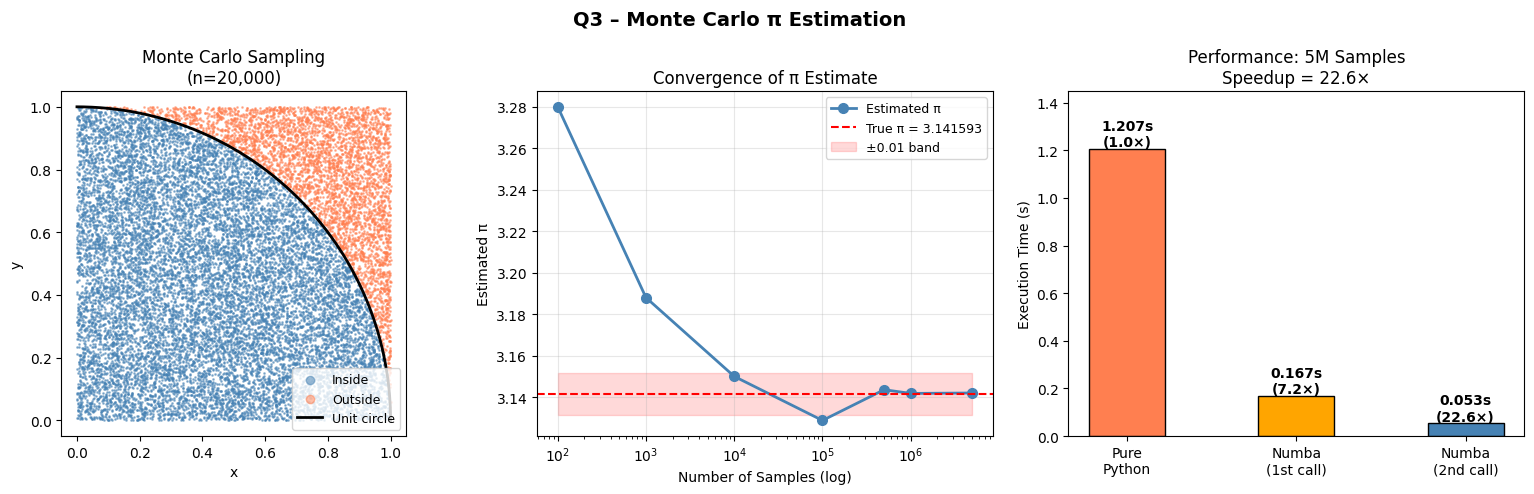

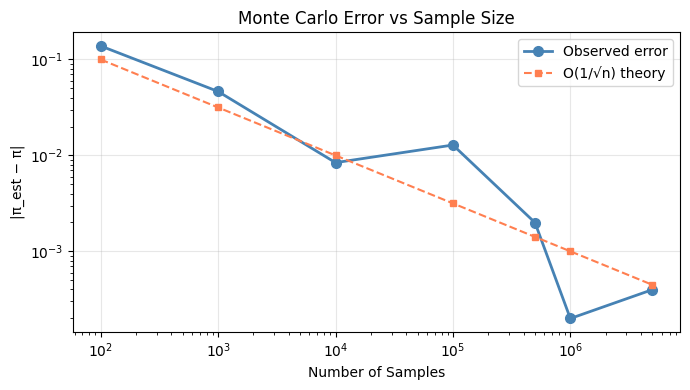


  FINAL SUMMARY — 5 Million Samples
  True π                  : 3.14159265
  Python estimate         : 3.14208480
  Numba estimate (2nd)    : 3.14117520
  Python time             : 1.2067 s
  Numba time (2nd call)   : 0.0534 s
  Speedup Factor          : 22.61×


In [4]:
# ============================================================
#  Q3: Monte Carlo π Estimation
#  Pure Python vs Numba JIT — 5 Million Samples
#  Colab-ready (CPU runtime is fine)
# ============================================================

import numpy as np
import numba
from numba import njit
import random
import time
import math
import matplotlib.pyplot as plt

print("Numba:", numba.__version__)

N = 5_000_000

# ─────────────────────────────────────────
#  3a — Pure Python Implementation
# ─────────────────────────────────────────

def monte_carlo_pi_python(nsamples):
    """
    Estimate π using Monte Carlo method.
    - Generate random (x, y) in [0, 1) × [0, 1)
    - Point is inside unit circle if x² + y² < 1
    - π ≈ 4 × (points inside circle / total points)
    """
    count = 0
    for _ in range(nsamples):
        x = random.random()
        y = random.random()
        if x*x + y*y < 1.0:
            count += 1
    return 4.0 * count / nsamples

# ─────────────────────────────────────────
#  3a — Numba JIT Implementation
# ─────────────────────────────────────────

@njit
def monte_carlo_pi_numba(nsamples):
    """
    Exact same logic as Python version.
    @njit compiles this to native machine code on first call.
    np.random.random() is supported inside @njit.
    """
    count = 0
    for _ in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if x*x + y*y < 1.0:
            count += 1
    return 4.0 * count / nsamples

# ─────────────────────────────────────────
#  3b — Timing: Pure Python
# ─────────────────────────────────────────

print("\n── Running Pure Python ──────────────────────────────")
t0     = time.perf_counter()
pi_py  = monte_carlo_pi_python(N)
py_time = time.perf_counter() - t0
print(f"π estimate : {pi_py:.6f}")
print(f"Error      : {abs(pi_py - math.pi):.6f}")
print(f"Time       : {py_time:.4f} s")

# ─────────────────────────────────────────
#  3b — Timing: Numba — 1st call (with JIT compile)
# ─────────────────────────────────────────

print("\n── Running Numba (1st call — includes JIT compile) ──")
t0          = time.perf_counter()
pi_nb_1     = monte_carlo_pi_numba(N)
nb_time_1st = time.perf_counter() - t0
print(f"π estimate : {pi_nb_1:.6f}")
print(f"Error      : {abs(pi_nb_1 - math.pi):.6f}")
print(f"Time       : {nb_time_1st:.4f} s  ← includes compilation")

# ─────────────────────────────────────────
#  3b — Timing: Numba — 2nd call (cached machine code)
# ─────────────────────────────────────────

print("\n── Running Numba (2nd call — pure execution) ────────")
t0          = time.perf_counter()
pi_nb_2     = monte_carlo_pi_numba(N)
nb_time_2nd = time.perf_counter() - t0
print(f"π estimate : {pi_nb_2:.6f}")
print(f"Error      : {abs(pi_nb_2 - math.pi):.6f}")
print(f"Time       : {nb_time_2nd:.4f} s")

# ─────────────────────────────────────────
#  3b — Speedup Factor
# ─────────────────────────────────────────

speedup_1st = py_time / nb_time_1st
speedup_2nd = py_time / nb_time_2nd

print("\n" + "="*50)
print(f"  Speedup (Python / Numba 1st) : {speedup_1st:>7.2f}×")
print(f"  Speedup (Python / Numba 2nd) : {speedup_2nd:>7.2f}×")
print(f"  Compile overhead             : {(nb_time_1st - nb_time_2nd)*1000:.1f} ms")
print("="*50)

# ─────────────────────────────────────────
#  CONVERGENCE: π estimate vs sample size
# ─────────────────────────────────────────

sample_sizes = [100, 1_000, 10_000, 100_000, 500_000,
                1_000_000, 5_000_000]
pi_estimates = []

for n in sample_sizes:
    est = monte_carlo_pi_numba(n)
    pi_estimates.append(est)
    print(f"  n={n:>9,}  →  π ≈ {est:.6f}  "
          f"  error = {abs(est - math.pi):.6f}")

# ─────────────────────────────────────────
#  VISUALISATION 1 — Scatter: inside vs outside
# ─────────────────────────────────────────

n_plot = 20_000
xs = np.random.rand(n_plot)
ys = np.random.rand(n_plot)
inside = xs**2 + ys**2 < 1.0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — Plot 1: scatter
theta = np.linspace(0, np.pi/2, 300)
axes[0].scatter(xs[ inside], ys[ inside], s=1, c='steelblue', alpha=0.5, label='Inside')
axes[0].scatter(xs[~inside], ys[~inside], s=1, c='coral',     alpha=0.5, label='Outside')
axes[0].plot(np.cos(theta), np.sin(theta), 'k-', lw=2, label='Unit circle')
axes[0].set_aspect('equal')
axes[0].set_title(f'Monte Carlo Sampling\n(n={n_plot:,})', fontsize=12)
axes[0].legend(markerscale=6, fontsize=9)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# — Plot 2: convergence of π
axes[1].semilogx(sample_sizes, pi_estimates, 'o-',
                 color='steelblue', lw=2, ms=7, label='Estimated π')
axes[1].axhline(math.pi, color='red', ls='--', lw=1.5, label=f'True π = {math.pi:.6f}')
axes[1].fill_between(sample_sizes,
                     [math.pi - 0.01]*len(sample_sizes),
                     [math.pi + 0.01]*len(sample_sizes),
                     alpha=0.15, color='red', label='±0.01 band')
axes[1].set_xlabel('Number of Samples (log)')
axes[1].set_ylabel('Estimated π')
axes[1].set_title('Convergence of π Estimate', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# — Plot 3: timing comparison
labels_t = ['Pure\nPython', 'Numba\n(1st call)', 'Numba\n(2nd call)']
times_t  = [py_time, nb_time_1st, nb_time_2nd]
colors_t = ['coral', 'orange', 'steelblue']
bars     = axes[2].bar(labels_t, times_t, color=colors_t,
                       edgecolor='black', width=0.45)

for bar, t, sp in zip(bars, times_t, [1, speedup_1st, speedup_2nd]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(times_t)*0.01,
                 f'{t:.3f}s\n({sp:.1f}×)',
                 ha='center', fontsize=10, fontweight='bold')

axes[2].set_ylabel('Execution Time (s)')
axes[2].set_title(f'Performance: 5M Samples\nSpeedup = {speedup_2nd:.1f}×', fontsize=12)
axes[2].set_ylim(0, max(times_t) * 1.2)

plt.suptitle('Q3 – Monte Carlo π Estimation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_monte_carlo_pi.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 2 — Error vs Sample Size
# ─────────────────────────────────────────

errors = [abs(e - math.pi) for e in pi_estimates]
theory = [1/math.sqrt(n) for n in sample_sizes]   # expected O(1/√n) decay

plt.figure(figsize=(7, 4))
plt.loglog(sample_sizes, errors,  'o-', color='steelblue',
           lw=2, ms=7, label='Observed error')
plt.loglog(sample_sizes, theory,  's--', color='coral',
           lw=1.5, ms=5, label='O(1/√n) theory')
plt.xlabel('Number of Samples'); plt.ylabel('|π_est − π|')
plt.title('Monte Carlo Error vs Sample Size')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3_convergence_error.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  FINAL SUMMARY
# ─────────────────────────────────────────

print("\n" + "="*55)
print("  FINAL SUMMARY — 5 Million Samples")
print("="*55)
print(f"  True π                  : {math.pi:.8f}")
print(f"  Python estimate         : {pi_py:.8f}")
print(f"  Numba estimate (2nd)    : {pi_nb_2:.8f}")
print(f"  Python time             : {py_time:.4f} s")
print(f"  Numba time (2nd call)   : {nb_time_2nd:.4f} s")
print(f"  Speedup Factor          : {speedup_2nd:.2f}×")
print("="*55)

Numba: 0.60.0

[4b] @vectorize (dynamic)  : 31.32 ms
     Input  sample : [22, 143, 141, 48, 120, 214]
     Output sample : [26, 171, 169, 57, 144, 255]

[ref] NumPy (np.minimum)   : 95.11 ms

[4c] @vectorize cpu serial : 30.54 ms  | speedup vs dynamic: 1.03×
[4c] @vectorize parallel   : 26.11 ms  | speedup vs dynamic: 1.20×  | speedup vs cpu: 1.17×

── Correctness ──────────────────────────────────────────
dynamic  matches NumPy : True
cpu      matches NumPy : True
parallel matches NumPy : True

Boundary test input  : [0, 1, 100, 200, 210, 213, 214, 220, 250, 255]
Boundary test output : [0, 1, 120, 240, 252, 255, 255, 255, 255, 255]
(Values ≥214 should clamp to 255 — 214 × 1.2 = 256.8 > 255)

── 4d: Passing a Python list ────────────────────────────

[dynamic @vectorize]
  Result : [120 180 240 255 255]
  Type   : <class 'numpy.ndarray'>
  → Silently converted list → NumPy array, worked fine.

[parallel @vectorize  ['int64(int64)']]
  Result : [120 180 240 255 255]
  Type   : <class '

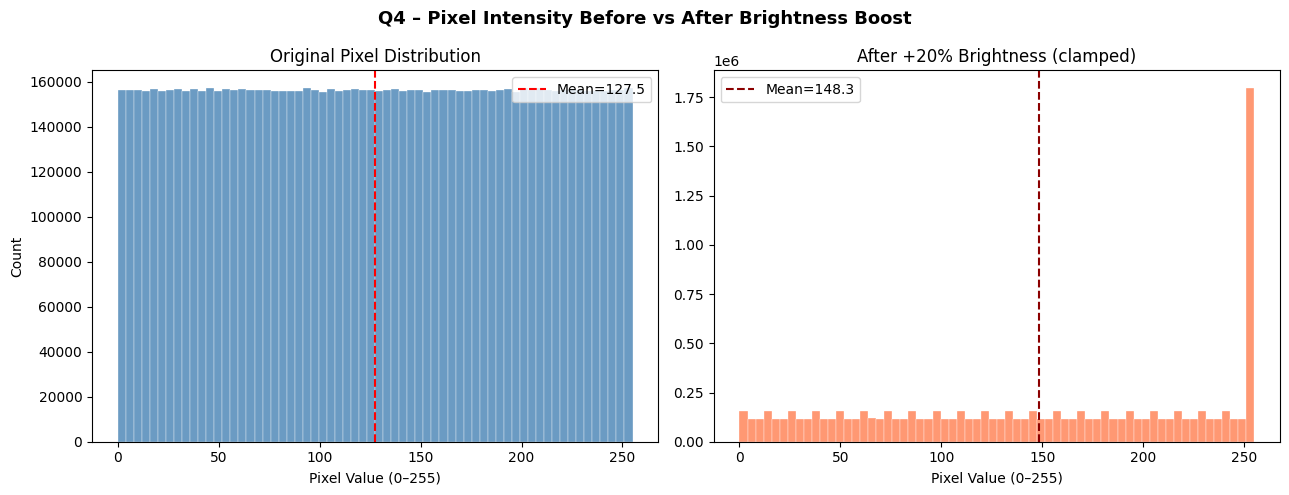

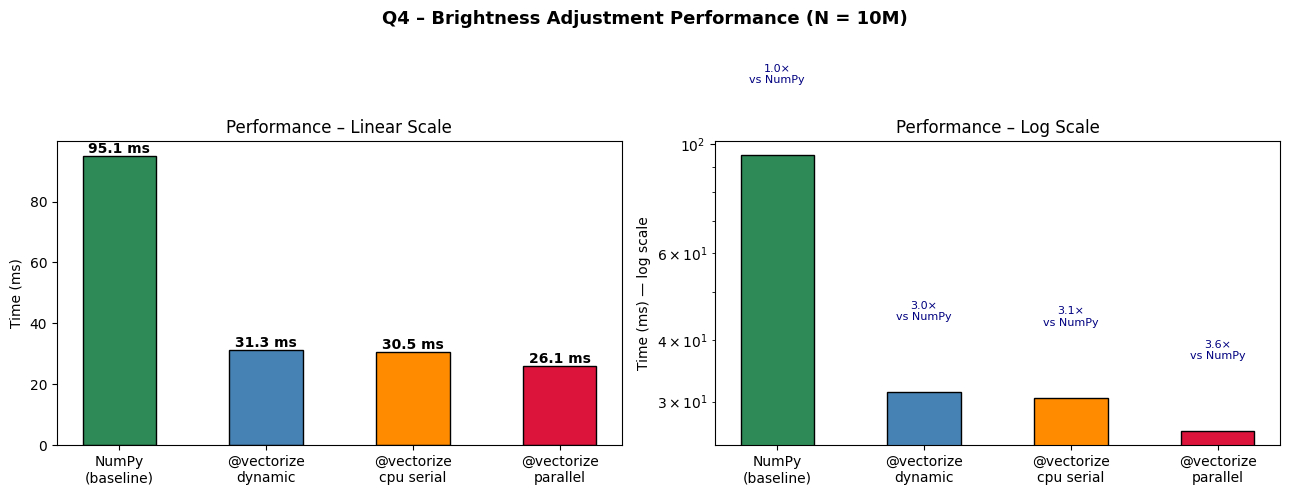


  Method                     Time (ms)   vs NumPy
  NumPy (baseline)               95.11      1.00×
  @vectorize dynamic             31.32      3.04×
  @vectorize cpu serial          30.54      3.11×
  @vectorize parallel            26.11      3.64×


In [5]:
# ============================================================
#  Q4: Pixel Brightness Adjustment with @vectorize
#  dynamic → typed → parallel target
#  Colab-ready (CPU runtime is fine)
# ============================================================

import numpy as np
import numba
from numba import vectorize
import time
import matplotlib.pyplot as plt

print("Numba:", numba.__version__)

N = 10_000_000
pixels = np.random.randint(0, 256, N, dtype=np.int64)

# ─────────────────────────────────────────
#  4a — @vectorize  (dynamic dispatch)
# ─────────────────────────────────────────

@vectorize
def adjust_brightness(pixel_value):
    """
    Increase brightness by 20%, clamp to 255.
    No type signature → Numba infers types at first call.
    Behaves like a NumPy ufunc after compilation.
    """
    result = pixel_value + pixel_value // 5    # integer 20%  (x + x/5)
    if result > 255:
        return numba.int64(255)
    return numba.int64(result)

# ─────────────────────────────────────────
#  4b — Apply to 10 million pixels
# ─────────────────────────────────────────

# warm-up call (triggers JIT compile — not included in benchmark)
_ = adjust_brightness(pixels[:10])

t0         = time.perf_counter()
out_dynamic = adjust_brightness(pixels)
t_dynamic   = time.perf_counter() - t0

print(f"\n[4b] @vectorize (dynamic)  : {t_dynamic*1000:.2f} ms")
print(f"     Input  sample : {pixels[:6].tolist()}")
print(f"     Output sample : {out_dynamic[:6].tolist()}")

# ─────────────────────────────────────────
#  NumPy baseline for comparison
# ─────────────────────────────────────────

t0      = time.perf_counter()
out_np  = np.minimum(pixels + pixels // 5, 255).astype(np.int64)
t_numpy = time.perf_counter() - t0
print(f"\n[ref] NumPy (np.minimum)   : {t_numpy*1000:.2f} ms")

# ─────────────────────────────────────────
#  4c — @vectorize with typed + CPU serial
# ─────────────────────────────────────────

@vectorize(['int64(int64)'], target='cpu')
def adjust_brightness_cpu(pixel_value):
    """
    Explicit int64 signature, serial CPU target.
    Avoids type-inference overhead of dynamic dispatch.
    """
    result = pixel_value + pixel_value // 5
    if result > 255:
        return numba.int64(255)
    return numba.int64(result)

_ = adjust_brightness_cpu(pixels[:10])   # warm-up

t0      = time.perf_counter()
out_cpu = adjust_brightness_cpu(pixels)
t_cpu   = time.perf_counter() - t0
print(f"\n[4c] @vectorize cpu serial : {t_cpu*1000:.2f} ms  "
      f"| speedup vs dynamic: {t_dynamic/t_cpu:.2f}×")

# ─────────────────────────────────────────
#  4c — @vectorize parallel target
# ─────────────────────────────────────────

@vectorize(['int64(int64)'], target='parallel')
def adjust_brightness_parallel(pixel_value):
    """
    Same logic — target='parallel' tells Numba to distribute
    the array across all available CPU cores automatically.
    No manual threading code needed.
    """
    result = pixel_value + pixel_value // 5
    if result > 255:
        return numba.int64(255)
    return numba.int64(result)

_ = adjust_brightness_parallel(pixels[:10])  # warm-up

t0       = time.perf_counter()
out_par  = adjust_brightness_parallel(pixels)
t_parallel = time.perf_counter() - t0

print(f"[4c] @vectorize parallel   : {t_parallel*1000:.2f} ms  "
      f"| speedup vs dynamic: {t_dynamic/t_parallel:.2f}×  "
      f"| speedup vs cpu: {t_cpu/t_parallel:.2f}×")

# ─────────────────────────────────────────
#  CORRECTNESS CHECK
# ─────────────────────────────────────────

print("\n── Correctness ──────────────────────────────────────────")
print(f"dynamic  matches NumPy : {np.array_equal(out_dynamic,  out_np)}")
print(f"cpu      matches NumPy : {np.array_equal(out_cpu,      out_np)}")
print(f"parallel matches NumPy : {np.array_equal(out_par,      out_np)}")

# Spot-check boundary values
test_vals = np.array([0, 1, 100, 200, 210, 213, 214, 220, 250, 255],
                     dtype=np.int64)
test_out  = adjust_brightness_parallel(test_vals)
print(f"\nBoundary test input  : {test_vals.tolist()}")
print(f"Boundary test output : {test_out.tolist()}")
print("(Values ≥214 should clamp to 255 — 214 × 1.2 = 256.8 > 255)")

# ─────────────────────────────────────────
#  4d — Pass a Python list instead of ndarray
# ─────────────────────────────────────────

print("\n── 4d: Passing a Python list ────────────────────────────")
test_list = [100, 150, 200, 250, 255]

# --- dynamic @vectorize ---
print("\n[dynamic @vectorize]")
try:
    result_dyn = adjust_brightness(test_list)
    print(f"  Result : {result_dyn}")
    print(f"  Type   : {type(result_dyn)}")
    print("  → Silently converted list → NumPy array, worked fine.")
except Exception as e:
    print(f"  Error  : {type(e).__name__}: {e}")

# --- parallel @vectorize ---
print("\n[parallel @vectorize  ['int64(int64)']]")
try:
    result_par = adjust_brightness_parallel(test_list)
    print(f"  Result : {result_par}")
    print(f"  Type   : {type(result_par)}")
    print("  → Numba converted list to ndarray before dispatch.")
except Exception as e:
    print(f"  Error  : {type(e).__name__}: {e}")
    print("  → Typed signature rejected the list — needs explicit np.array.")
    # correct way
    result_fixed = adjust_brightness_parallel(
        np.array(test_list, dtype=np.int64))
    print(f"  Fixed  : {result_fixed.tolist()}")

# ─────────────────────────────────────────
#  VISUALISATION 1 — Before / After histogram
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(pixels,  bins=64, range=(0, 255), color='steelblue',
             alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].set_title('Original Pixel Distribution', fontsize=12)
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Count')
axes[0].axvline(pixels.mean(), color='red', ls='--',
                label=f'Mean={pixels.mean():.1f}')
axes[0].legend()

axes[1].hist(out_par, bins=64, range=(0, 255), color='coral',
             alpha=0.8, edgecolor='white', linewidth=0.3)
axes[1].set_title('After +20% Brightness (clamped)', fontsize=12)
axes[1].set_xlabel('Pixel Value (0–255)')
axes[1].axvline(out_par.mean(), color='darkred', ls='--',
                label=f'Mean={out_par.mean():.1f}')
axes[1].legend()

plt.suptitle('Q4 – Pixel Intensity Before vs After Brightness Boost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_pixel_distribution.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 2 — Performance bar chart
# ─────────────────────────────────────────

labels  = ['NumPy\n(baseline)', '@vectorize\ndynamic',
           '@vectorize\ncpu serial', '@vectorize\nparallel']
times   = [t_numpy*1000, t_dynamic*1000, t_cpu*1000, t_parallel*1000]
colors  = ['seagreen', 'steelblue', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# linear scale
bars = axes[0].bar(labels, times, color=colors, edgecolor='black', width=0.5)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(times)*0.01,
                 f'{t:.1f} ms', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Performance – Linear Scale')

# log scale
axes[1].bar(labels, times, color=colors, edgecolor='black', width=0.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Time (ms) — log scale')
axes[1].set_title('Performance – Log Scale')
for bar, t in zip(axes[1].patches, times):
    sp = t_dynamic / (t/1000) if t > 0 else 0
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 t * 1.4,
                 f'{t_numpy*1000/t:.1f}×\nvs NumPy',
                 ha='center', fontsize=8, color='navy')

plt.suptitle('Q4 – Brightness Adjustment Performance (N = 10M)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_performance.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  SUMMARY TABLE
# ─────────────────────────────────────────

print("\n" + "="*60)
print(f"  {'Method':<25} {'Time (ms)':>10} {'vs NumPy':>10}")
print("="*60)
for lbl, t in zip(labels, times):
    lbl_c = lbl.replace('\n', ' ')
    print(f"  {lbl_c:<25} {t:>10.2f} {t_numpy*1000/t:>9.2f}×")
print("="*60)

Numba: 0.60.0

Dataset : 100000 samples | 10 features
Class balance : +1 → 49797 | -1 → 50203
Epochs : 200 | LR : 0.01

[NumPy]  Time : 2196.37 ms  | Final loss : 0.488746
[Numba]  Time : 829.18 ms  | Final loss : 0.488746

Speedup (NumPy / Numba) : 2.65×

── Correctness ──────────────────────────────────────────────
Accuracy  NumPy  : 99.7050%
Accuracy  Numba  : 99.7050%
Weight L2 diff   : 3.41e-16   (should be ~0)
Final loss diff  : 3.61e-15   (should be ~0)
Weights match (atol=1e-6) : True

── Per-Weight Comparison ────────────────────────────────────
    j       w_numpy       w_numba        |diff|
  ---------------------------------------------
    0    0.04149885    0.04149885      6.94e-18
    1   -0.02785441   -0.02785441      1.39e-17
    2    0.25505041    0.25505041      1.67e-16
    3    0.04189848    0.04189848      1.39e-17
    4    0.19065882    0.19065882      2.78e-17
    5    0.30983507    0.30983507      2.78e-16
    6    0.11578550    0.11578550      2.78e-17
    7  

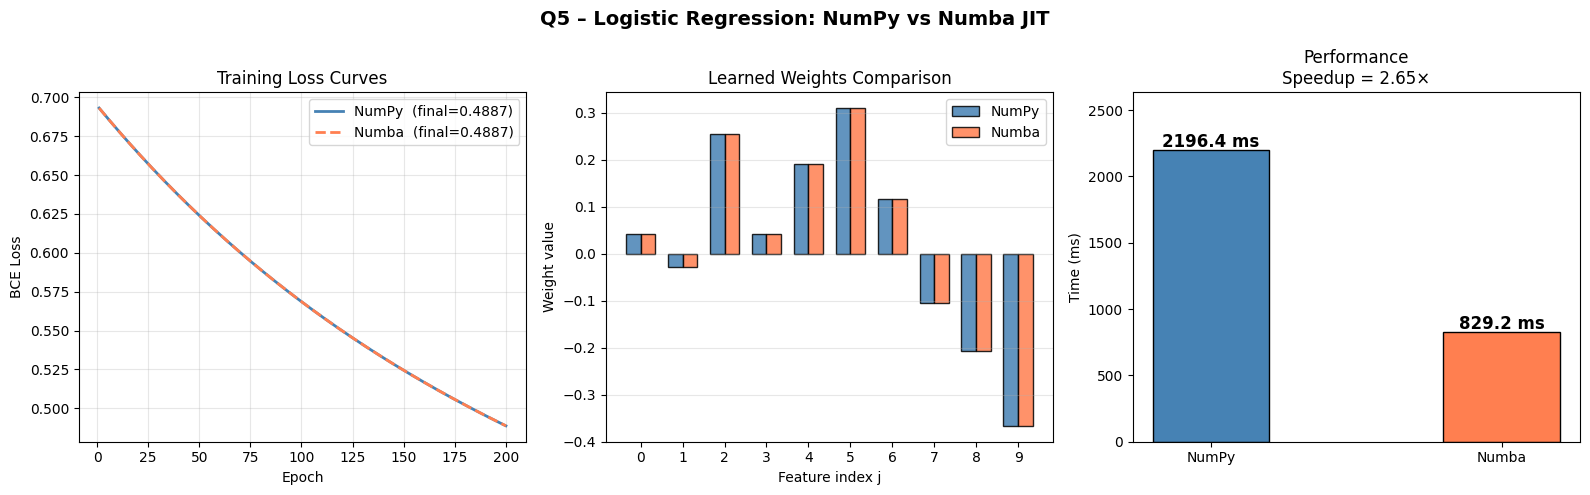

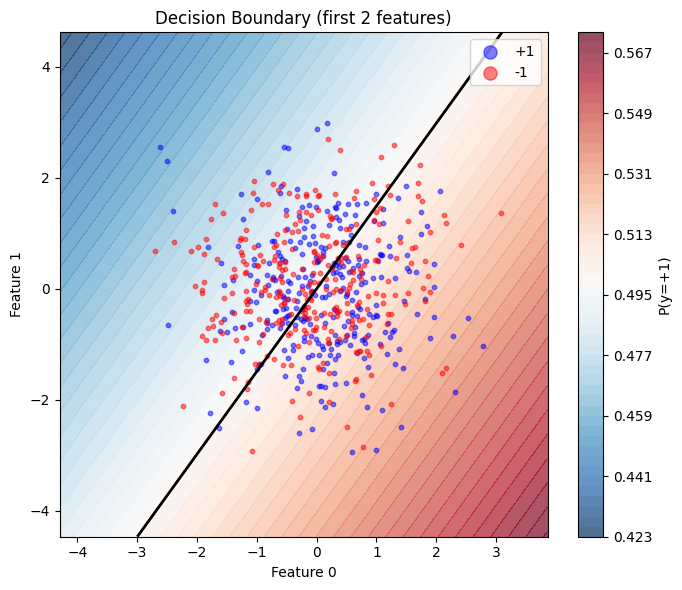


  FINAL SUMMARY
  Metric                              NumPy      Numba
  --------------------------------------------------
  Time (ms)                         2196.37     829.18
  Final BCE Loss                   0.488746   0.488746
  Accuracy (%)                      99.7050    99.7050
  Weight L2 diff                          —   3.41e-16
  Speedup                             1.00×      2.65×


In [6]:
# ============================================================
#  Q5: Binary Logistic Regression — NumPy vs Numba JIT
#  100,000 samples | 10 features | labels {-1, +1}
#  Colab-ready (CPU runtime is fine)
# ============================================================

import numpy as np
import numba
from numba import njit
import time
import math
import matplotlib.pyplot as plt

print("Numba:", numba.__version__)

# ─────────────────────────────────────────
#  DATASET GENERATION
# ─────────────────────────────────────────

np.random.seed(42)
N_SAMPLES  = 100_000
N_FEATURES = 10
EPOCHS     = 200
LR         = 0.01

# Features: standard normal
X = np.random.randn(N_SAMPLES, N_FEATURES)

# True weights to generate separable-ish labels
w_true  = np.random.randn(N_FEATURES)
logits  = X @ w_true
probs   = 1.0 / (1.0 + np.exp(-logits))

# Labels in {-1, +1}
y = np.where(probs >= 0.5, 1.0, -1.0)

print(f"\nDataset : {N_SAMPLES} samples | {N_FEATURES} features")
print(f"Class balance : +1 → {(y==1).sum()} | -1 → {(y==-1).sum()}")
print(f"Epochs : {EPOCHS} | LR : {LR}")

# ─────────────────────────────────────────
#  MATH BACKGROUND
# ─────────────────────────────────────────
#
#  Sigmoid  :  σ(z) = 1 / (1 + e^{-z})
#
#  Convert labels {-1,+1} → {0,1} for BCE:
#      y₀₁ = (y + 1) / 2
#
#  Prediction  :  p = σ(X · w)
#
#  BCE Loss    :  L = −(1/N) Σ [ y₀₁ log(p) + (1−y₀₁) log(1−p) ]
#
#  Gradient    :  ∇w = (1/N) Xᵀ (p − y₀₁)
#
#  Update      :  w ← w − lr · ∇w
#

# ─────────────────────────────────────────
#  5a — NumPy Implementation
# ─────────────────────────────────────────

def sigmoid_np(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss_np(p, y01):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y01 * np.log(p) + (1 - y01) * np.log(1 - p))

def logistic_regression_numpy(X, y, lr, epochs):
    """
    Gradient descent logistic regression — pure NumPy.

    Steps per epoch:
      1. Forward  : p = σ(Xw)
      2. Loss     : BCE(p, y₀₁)
      3. Gradient : ∇w = Xᵀ(p − y₀₁) / N
      4. Update   : w ← w − lr·∇w
    """
    n, d  = X.shape
    w     = np.zeros(d)
    y01   = (y + 1.0) / 2.0          # {-1,+1} → {0,1}
    losses = np.zeros(epochs)

    for epoch in range(epochs):
        p          = sigmoid_np(X @ w)            # (N,)
        grad       = X.T @ (p - y01) / n         # (d,)
        w         -= lr * grad
        losses[epoch] = bce_loss_np(p, y01)

    return w, losses

t0 = time.perf_counter()
w_np, loss_np = logistic_regression_numpy(X, y, LR, EPOCHS)
t_numpy = time.perf_counter() - t0
print(f"\n[NumPy]  Time : {t_numpy*1000:.2f} ms  | Final loss : {loss_np[-1]:.6f}")

# ─────────────────────────────────────────
#  5b — Numba JIT Implementation
# ─────────────────────────────────────────

@njit
def sigmoid_nb(z):
    return 1.0 / (1.0 + math.exp(-z))

@njit
def bce_loss_nb(p, y01, n):
    loss = 0.0
    for i in range(n):
        pi = min(max(p[i], 1e-15), 1.0 - 1e-15)
        loss -= y01[i] * math.log(pi) + (1.0 - y01[i]) * math.log(1.0 - pi)
    return loss / n

@njit
def logistic_regression_numba(X, y, lr, epochs):
    """
    Exact same math as NumPy version — written as explicit loops.
    Numba compiles every loop to native machine code.

    Inner loop structure:
      For each epoch:
        → Forward pass  : p[i] = σ(Σⱼ X[i,j]·w[j])
        → Gradient      : grad[j] += X[i,j]·(p[i] − y01[i])
        → Weight update : w[j] -= lr · grad[j] / N
    """
    n, d   = X.shape
    w      = np.zeros(d)
    y01    = (y + 1.0) / 2.0
    losses = np.zeros(epochs)
    p      = np.zeros(n)

    for epoch in range(epochs):

        # ── Forward pass ──────────────────
        for i in range(n):
            z = 0.0
            for j in range(d):
                z += X[i, j] * w[j]
            p[i] = sigmoid_nb(z)

        # ── Gradient + update ─────────────
        grad = np.zeros(d)
        for i in range(n):
            err = p[i] - y01[i]
            for j in range(d):
                grad[j] += X[i, j] * err

        for j in range(d):
            w[j] -= lr * grad[j] / n

        losses[epoch] = bce_loss_nb(p, y01, n)

    return w, losses

# warm-up on tiny data (JIT compile — not benchmarked)
_Xs = X[:200]; _ys = y[:200]
_ = logistic_regression_numba(_Xs, _ys, LR, 2)

t0 = time.perf_counter()
w_nb, loss_nb = logistic_regression_numba(X, y, LR, EPOCHS)
t_numba = time.perf_counter() - t0
print(f"[Numba]  Time : {t_numba*1000:.2f} ms  | Final loss : {loss_nb[-1]:.6f}")
print(f"\nSpeedup (NumPy / Numba) : {t_numpy/t_numba:.2f}×")

# ─────────────────────────────────────────
#  5c — CORRECTNESS CHECK
# ─────────────────────────────────────────

def sigmoid_np(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict(X, w, threshold=0.5):
    return np.where(sigmoid_np(X @ w) >= threshold, 1.0, -1.0)

acc_np = np.mean(predict(X, w_np) == y) * 100
acc_nb = np.mean(predict(X, w_nb) == y) * 100

weight_diff = np.linalg.norm(w_np - w_nb)
loss_diff   = abs(loss_np[-1] - loss_nb[-1])

print("\n── Correctness ──────────────────────────────────────────────")
print(f"Accuracy  NumPy  : {acc_np:.4f}%")
print(f"Accuracy  Numba  : {acc_nb:.4f}%")
print(f"Weight L2 diff   : {weight_diff:.2e}   (should be ~0)")
print(f"Final loss diff  : {loss_diff:.2e}   (should be ~0)")
print(f"Weights match (atol=1e-6) : {np.allclose(w_np, w_nb, atol=1e-6)}")

# Per-weight comparison table
print("\n── Per-Weight Comparison ────────────────────────────────────")
print(f"  {'j':>3}  {'w_numpy':>12}  {'w_numba':>12}  {'|diff|':>12}")
print("  " + "-"*45)
for j in range(N_FEATURES):
    print(f"  {j:>3}  {w_np[j]:>12.8f}  {w_nb[j]:>12.8f}  "
          f"{abs(w_np[j]-w_nb[j]):>12.2e}")

# ─────────────────────────────────────────
#  VISUALISATION 1 — Loss curves
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

epochs_x = np.arange(1, EPOCHS + 1)

axes[0].plot(epochs_x, loss_np, color='steelblue', lw=2,
             label=f'NumPy  (final={loss_np[-1]:.4f})')
axes[0].plot(epochs_x, loss_nb, color='coral', lw=2,
             ls='--', label=f'Numba  (final={loss_nb[-1]:.4f})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss Curves', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ─────────────────────────────────────────
#  VISUALISATION 2 — Weight convergence
# ─────────────────────────────────────────

x_pos = np.arange(N_FEATURES)
width = 0.35
axes[1].bar(x_pos - width/2, w_np, width, label='NumPy',
            color='steelblue', edgecolor='black', alpha=0.85)
axes[1].bar(x_pos + width/2, w_nb, width, label='Numba',
            color='coral',     edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Feature index j')
axes[1].set_ylabel('Weight value')
axes[1].set_title('Learned Weights Comparison', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────
#  VISUALISATION 3 — Performance bar
# ─────────────────────────────────────────

labels_t = ['NumPy', 'Numba']
times_t  = [t_numpy * 1000, t_numba * 1000]
colors_t = ['steelblue', 'coral']

bars = axes[2].bar(labels_t, times_t, color=colors_t,
                   edgecolor='black', width=0.4)
for bar, t in zip(bars, times_t):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(times_t) * 0.01,
                 f'{t:.1f} ms', ha='center',
                 fontsize=12, fontweight='bold')

axes[2].set_ylabel('Time (ms)')
axes[2].set_title(f'Performance\nSpeedup = {t_numpy/t_numba:.2f}×', fontsize=12)
axes[2].set_ylim(0, max(times_t) * 1.2)

plt.suptitle('Q5 – Logistic Regression: NumPy vs Numba JIT',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q5_logistic_regression.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 4 — Decision boundary (2 features)
# ─────────────────────────────────────────

X2 = X[:, :2]
w2 = w_np[:2]

xx = np.linspace(X2[:, 0].min(), X2[:, 0].max(), 300)
yy = np.linspace(X2[:, 1].min(), X2[:, 1].max(), 300)
XX, YY = np.meshgrid(xx, yy)
grid   = np.c_[XX.ravel(), YY.ravel()]
ZZ     = (1.0 / (1.0 + np.exp(-grid @ w2))).reshape(300, 300)

plt.figure(figsize=(7, 6))
plt.contourf(XX, YY, ZZ, levels=50, cmap='RdBu_r', alpha=0.7)
plt.colorbar(label='P(y=+1)')
plt.contour(XX, YY, ZZ, levels=[0.5], colors='black', linewidths=2)
idx_pos = np.where(y == +1)[0][:300]
idx_neg = np.where(y == -1)[0][:300]
plt.scatter(X2[idx_pos, 0], X2[idx_pos, 1], c='blue',
            s=10, alpha=0.5, label='+1')
plt.scatter(X2[idx_neg, 0], X2[idx_neg, 1], c='red',
            s=10, alpha=0.5, label='-1')
plt.title('Decision Boundary (first 2 features)', fontsize=12)
plt.xlabel('Feature 0'); plt.ylabel('Feature 1')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('q5_decision_boundary.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  FINAL SUMMARY
# ─────────────────────────────────────────

print("\n" + "="*55)
print("  FINAL SUMMARY")
print("="*55)
print(f"  {'Metric':<30} {'NumPy':>10} {'Numba':>10}")
print("  " + "-"*50)
print(f"  {'Time (ms)':<30} {t_numpy*1000:>10.2f} {t_numba*1000:>10.2f}")
print(f"  {'Final BCE Loss':<30} {loss_np[-1]:>10.6f} {loss_nb[-1]:>10.6f}")
print(f"  {'Accuracy (%)':<30} {acc_np:>10.4f} {acc_nb:>10.4f}")
print(f"  {'Weight L2 diff':<30} {'—':>10} {weight_diff:>10.2e}")
print(f"  {'Speedup':<30} {'1.00×':>10} {t_numpy/t_numba:>9.2f}×")
print("="*55)

Numba       : 0.60.0
CUDA available: True
Found 1 CUDA devices
id 0                Tesla T4                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-7735a56d-d82f-dc0f-c38b-4ca09066b4a3
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported

Matrix size : 1024 × 1024 = 1,048,576 elements
Memory each : 4096.0 KB  (float32)
Total GPU   : 12288.0 KB  (A + B + C)

── Thread Configuration ───────────────────────────────
  2-D block  : (16, 16)  = 256 threads/block
  2-D grid   : (64, 64)  = 4096 blocks
  Total 2-D  : 1024 × 1024 = 1,048,576 threads

  1-D block  : 256 threads/block
  1-D grid   : 4096 blocks
  Total 1-D  : 1,048,576 threads

[CPU NumPy]    0.565 ± 0.052 ms
[GPU 1-D]      0.1368 ± 0.0168 ms  | Speedup: 4.1×
[GPU 2-D]      0.2237 ± 0.0757 

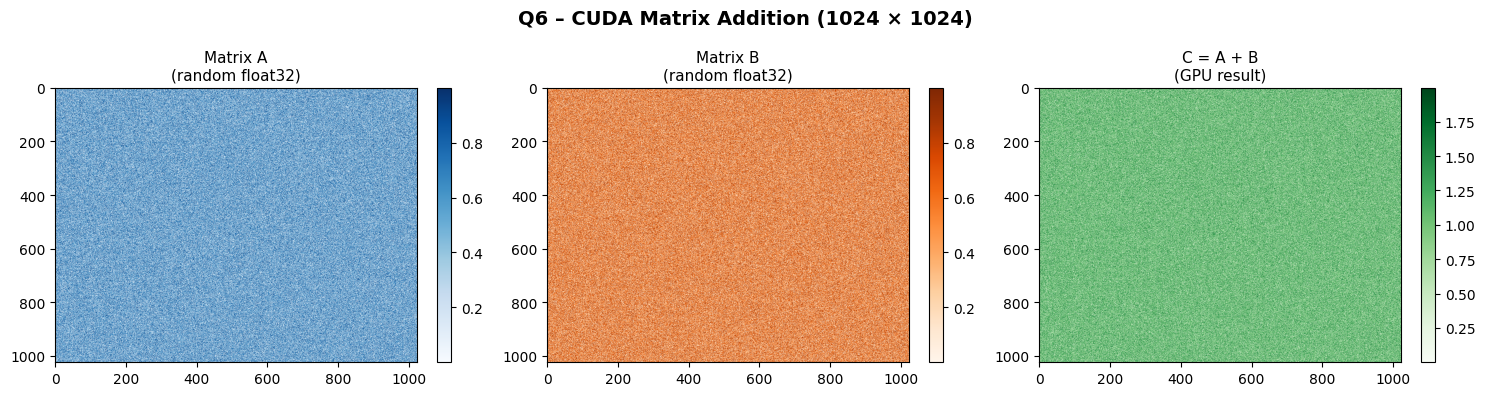

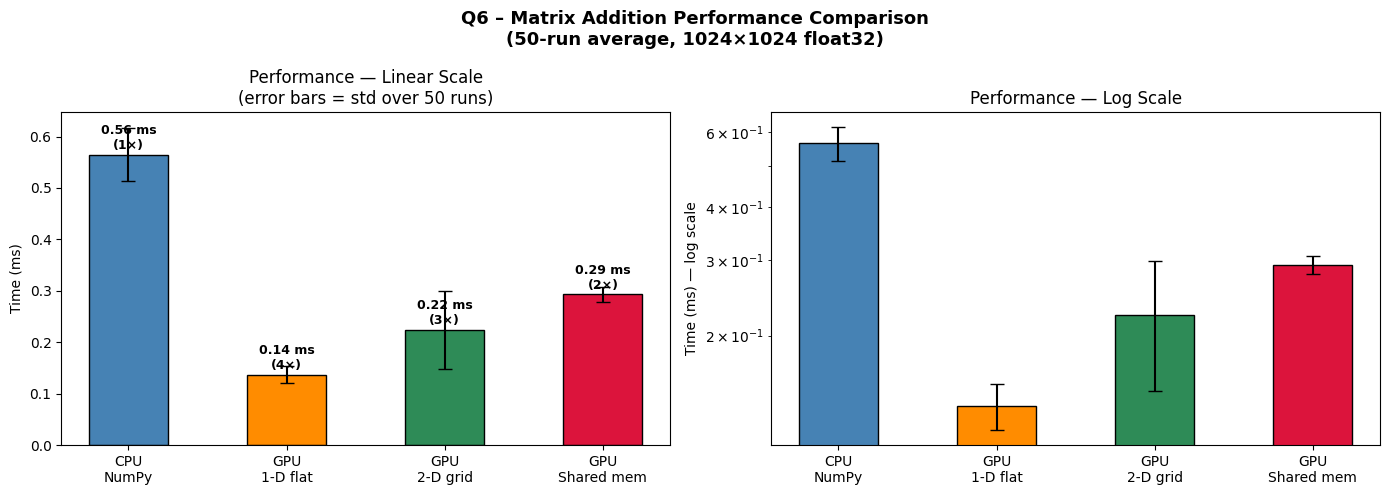

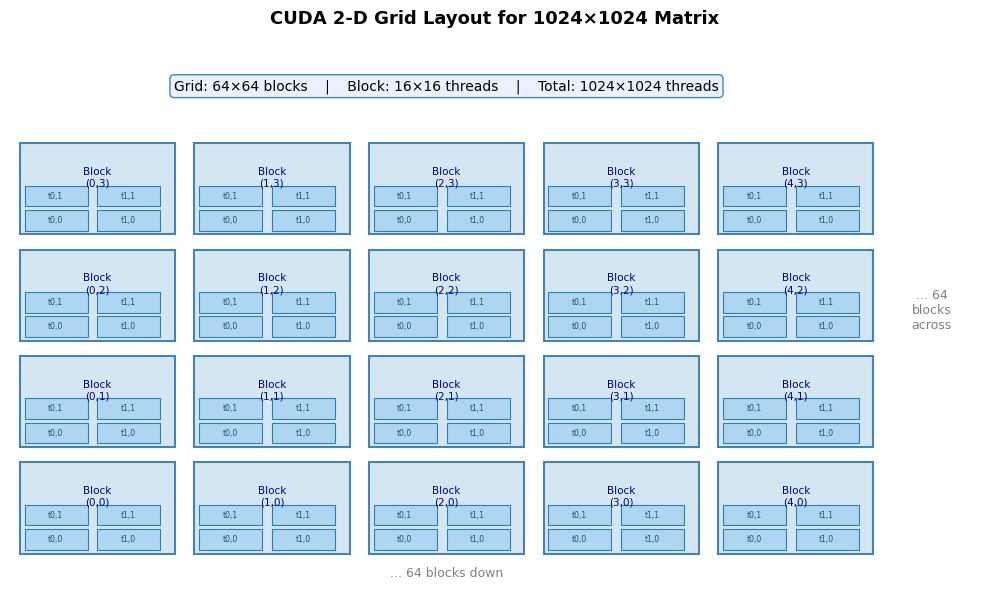


  FINAL SUMMARY  —  1024×1024 float32  (50-run average)
  Method                 Time(ms)    Speedup   BW(GB/s)
  ----------------------------------------------------------
  CPU NumPy                0.5649       1.0×     22.28
  GPU 1-D flat             0.1368       4.1×     91.96
  GPU 2-D grid             0.2237       2.5×     56.24
  GPU shared               0.2929       1.9×     42.97


In [9]:
# ============================================================
#  Q6: CUDA Matrix Addition  A + B = C  (1024 × 1024)
#  Numba CUDA kernel — Colab T4 GPU runtime required
# ============================================================

import numpy as np
import numba
from numba import cuda
import time
import math
import matplotlib.pyplot as plt

print("Numba       :", numba.__version__)
print("CUDA available:", cuda.is_available())
cuda.detect()

ROWS = 1024
COLS = 1024

# ─────────────────────────────────────────
#  CUDA KERNELS
# ─────────────────────────────────────────

# ── Kernel 1: 1-D flat indexing ──────────────────────────────
@cuda.jit
def matrix_add_1d(A, B, C, rows, cols):
    """
    Each thread computes one element using a flat global index.
    Flattened index: i = blockIdx.x * blockDim.x + threadIdx.x
    Row = i // cols,  Col = i % cols
    """
    i = cuda.grid(1)
    if i < rows * cols:
        row = i // cols
        col = i % cols
        C[row, col] = A[row, col] + B[row, col]

# ── Kernel 2: 2-D grid indexing (recommended for matrices) ───
@cuda.jit
def matrix_add_2d(A, B, C):
    """
    2-D thread grid — each thread maps directly to (row, col).
    cuda.grid(2) returns (global_row, global_col).
    Boundary guard handles non-multiple-of-blocksize matrices.
    """
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        C[row, col] = A[row, col] + B[row, col]

# ── Kernel 3: 2-D with shared memory ─────────────────────────
TILE = 16    # tile size must match blockdim below

@cuda.jit
def matrix_add_shared(A, B, C):
    """
    Loads tile of A and B into shared memory first.
    Shared memory is on-chip SRAM — ~100× faster than global DRAM.
    For simple addition the gain is small, but pattern is important
    for matmul, convolution, etc.
    """
    # Allocate shared memory tiles — size fixed at compile time
    s_A = cuda.shared.array(shape=(TILE, TILE), dtype=numba.float32)
    s_B = cuda.shared.array(shape=(TILE, TILE), dtype=numba.float32)

    row = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
    col = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    tx  = cuda.threadIdx.x
    ty  = cuda.threadIdx.y

    # Load global → shared
    if row < A.shape[0] and col < A.shape[1]:
        s_A[tx, ty] = A[row, col]
        s_B[tx, ty] = B[row, col]
    else:
        s_A[tx, ty] = 0.0
        s_B[tx, ty] = 0.0

    # Synchronise — all threads must finish loading before compute
    cuda.syncthreads()

    # Compute from shared memory → global
    if row < C.shape[0] and col < C.shape[1]:
        C[row, col] = s_A[tx, ty] + s_B[tx, ty]

# ─────────────────────────────────────────
#  HOST MATRICES
# ─────────────────────────────────────────

A = np.random.rand(ROWS, COLS).astype(np.float32)
B = np.random.rand(ROWS, COLS).astype(np.float32)
C_ref = A + B                          # NumPy reference

print(f"\nMatrix size : {ROWS} × {COLS} = {ROWS*COLS:,} elements")
print(f"Memory each : {A.nbytes / 1024:.1f} KB  (float32)")
print(f"Total GPU   : {3 * A.nbytes / 1024:.1f} KB  (A + B + C)")

# ─────────────────────────────────────────
#  THREAD / BLOCK / GRID CONFIG
# ─────────────────────────────────────────

# 2-D config — 16×16 block = 256 threads (sweet spot for most GPUs)
THREADS_2D = (16, 16)
BLOCKS_2D  = (
    math.ceil(ROWS / THREADS_2D[0]),
    math.ceil(COLS / THREADS_2D[1])
)

# 1-D config
THREADS_1D = 256
BLOCKS_1D  = math.ceil((ROWS * COLS) / THREADS_1D)

print(f"\n── Thread Configuration ───────────────────────────────")
print(f"  2-D block  : {THREADS_2D}  = {THREADS_2D[0]*THREADS_2D[1]} threads/block")
print(f"  2-D grid   : {BLOCKS_2D}  = {BLOCKS_2D[0]*BLOCKS_2D[1]} blocks")
print(f"  Total 2-D  : {BLOCKS_2D[0]*THREADS_2D[0]} × "
      f"{BLOCKS_2D[1]*THREADS_2D[1]} = "
      f"{BLOCKS_2D[0]*THREADS_2D[0]*BLOCKS_2D[1]*THREADS_2D[1]:,} threads")
print(f"\n  1-D block  : {THREADS_1D} threads/block")
print(f"  1-D grid   : {BLOCKS_1D} blocks")
print(f"  Total 1-D  : {BLOCKS_1D * THREADS_1D:,} threads")

# ─────────────────────────────────────────
#  TRANSFER TO GPU
# ─────────────────────────────────────────

d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.device_array((ROWS, COLS), dtype=np.float32)

# ─────────────────────────────────────────
#  BENCHMARK HELPER
# ─────────────────────────────────────────

def benchmark(kernel_fn, n_runs=50):
    """Run kernel n_runs times, return mean time (seconds)."""
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        kernel_fn()
        cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return np.mean(times), np.std(times)

# ─────────────────────────────────────────
#  CPU BASELINE
# ─────────────────────────────────────────

# warm-up NumPy
_ = A + B

cpu_mean, cpu_std = benchmark(lambda: np.add(A, B))
print(f"\n[CPU NumPy]    {cpu_mean*1000:.3f} ± {cpu_std*1000:.3f} ms")

# ─────────────────────────────────────────
#  KERNEL 1: 1-D FLAT
# ─────────────────────────────────────────

# warm-up (JIT compile)
matrix_add_1d[BLOCKS_1D, THREADS_1D](d_A, d_B, d_C, ROWS, COLS)
cuda.synchronize()

mean_1d, std_1d = benchmark(
    lambda: matrix_add_1d[BLOCKS_1D, THREADS_1D](d_A, d_B, d_C, ROWS, COLS)
)
out_1d = d_C.copy_to_host()
print(f"[GPU 1-D]      {mean_1d*1000:.4f} ± {std_1d*1000:.4f} ms  "
      f"| Speedup: {cpu_mean/mean_1d:.1f}×")

# ─────────────────────────────────────────
#  KERNEL 2: 2-D GRID
# ─────────────────────────────────────────

matrix_add_2d[BLOCKS_2D, THREADS_2D](d_A, d_B, d_C)
cuda.synchronize()

mean_2d, std_2d = benchmark(
    lambda: matrix_add_2d[BLOCKS_2D, THREADS_2D](d_A, d_B, d_C)
)
out_2d = d_C.copy_to_host()
print(f"[GPU 2-D]      {mean_2d*1000:.4f} ± {std_2d*1000:.4f} ms  "
      f"| Speedup: {cpu_mean/mean_2d:.1f}×")

# ─────────────────────────────────────────
#  KERNEL 3: SHARED MEMORY
# ─────────────────────────────────────────

matrix_add_shared[BLOCKS_2D, THREADS_2D](d_A, d_B, d_C)
cuda.synchronize()

mean_sh, std_sh = benchmark(
    lambda: matrix_add_shared[BLOCKS_2D, THREADS_2D](d_A, d_B, d_C)
)
out_sh = d_C.copy_to_host()
print(f"[GPU shared]   {mean_sh*1000:.4f} ± {std_sh*1000:.4f} ms  "
      f"| Speedup: {cpu_mean/mean_sh:.1f}×")

# ─────────────────────────────────────────
#  CORRECTNESS
# ─────────────────────────────────────────

print("\n── Correctness (allclose, atol=1e-5) ───────────────────")
print(f"  1-D kernel    : {np.allclose(out_1d, C_ref, atol=1e-5)}"
      f"  | max err: {np.max(np.abs(out_1d - C_ref)):.2e}")
print(f"  2-D kernel    : {np.allclose(out_2d, C_ref, atol=1e-5)}"
      f"  | max err: {np.max(np.abs(out_2d - C_ref)):.2e}")
print(f"  Shared memory : {np.allclose(out_sh, C_ref, atol=1e-5)}"
      f"  | max err: {np.max(np.abs(out_sh - C_ref)):.2e}")

# ─────────────────────────────────────────
#  BANDWIDTH ANALYSIS
# ─────────────────────────────────────────

bytes_moved = 3 * A.nbytes          # read A, read B, write C
bw_cpu   = bytes_moved / cpu_mean  / 1e9
bw_1d    = bytes_moved / mean_1d   / 1e9
bw_2d    = bytes_moved / mean_2d   / 1e9
bw_sh    = bytes_moved / mean_sh   / 1e9

print("\n── Memory Bandwidth ────────────────────────────────────")
print(f"  Bytes moved  : {bytes_moved / 1024:.1f} KB  "
      f"(read A + read B + write C)")
print(f"  CPU NumPy    : {bw_cpu:.2f} GB/s")
print(f"  GPU 1-D      : {bw_1d:.2f} GB/s")
print(f"  GPU 2-D      : {bw_2d:.2f} GB/s")
print(f"  GPU shared   : {bw_sh:.2f} GB/s")

# ─────────────────────────────────────────
#  VISUALISATION 1 — Matrix heatmaps
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(A,      cmap='Blues',   aspect='auto')
axes[0].set_title('Matrix A\n(random float32)', fontsize=11)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(B,      cmap='Oranges', aspect='auto')
axes[1].set_title('Matrix B\n(random float32)', fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(out_2d, cmap='Greens',  aspect='auto')
axes[2].set_title('C = A + B\n(GPU result)', fontsize=11)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('Q6 – CUDA Matrix Addition (1024 × 1024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q6_matrices.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 2 — Performance bars
# ─────────────────────────────────────────

labels_p = ['CPU\nNumPy', 'GPU\n1-D flat', 'GPU\n2-D grid', 'GPU\nShared mem']
means_p  = [cpu_mean*1000, mean_1d*1000, mean_2d*1000, mean_sh*1000]
stds_p   = [cpu_std*1000,  std_1d*1000,  std_2d*1000,  std_sh*1000]
colors_p = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# linear
bars = axes[0].bar(labels_p, means_p, color=colors_p,
                   edgecolor='black', width=0.5,
                   yerr=stds_p, capsize=5)
for bar, m, sp in zip(bars, means_p,
                       [1, cpu_mean/mean_1d,
                        cpu_mean/mean_2d, cpu_mean/mean_sh]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(means_p)*0.02,
                 f'{m:.2f} ms\n({sp:.0f}×)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Performance — Linear Scale\n(error bars = std over 50 runs)')

# log
axes[1].bar(labels_p, means_p, color=colors_p,
            edgecolor='black', width=0.5,
            yerr=stds_p, capsize=5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Time (ms) — log scale')
axes[1].set_title('Performance — Log Scale')

plt.suptitle('Q6 – Matrix Addition Performance Comparison\n'
             f'(50-run average, 1024×1024 float32)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q6_performance.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  VISUALISATION 3 — Grid/Block diagram
# ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 7); ax.axis('off')
ax.set_title('CUDA 2-D Grid Layout for 1024×1024 Matrix',
             fontsize=13, fontweight='bold', pad=15)

# Draw grid of blocks
for bx in range(5):
    for by in range(4):
        rect = plt.Rectangle((bx*1.8 + 0.1, by*1.4 + 0.3),
                               1.6, 1.2,
                               fill=True, facecolor='#d4e6f1',
                               edgecolor='steelblue', lw=1.5)
        ax.add_patch(rect)
        ax.text(bx*1.8 + 0.9, by*1.4 + 1.05,
                f'Block\n({bx},{by})',
                ha='center', va='center', fontsize=7.5,
                color='navy')

        # inner threads (2×2 mini-grid)
        for tx in range(2):
            for ty in range(2):
                mini = plt.Rectangle(
                    (bx*1.8 + 0.15 + tx*0.75,
                     by*1.4 + 0.35 + ty*0.32),
                    0.65, 0.27,
                    fill=True, facecolor='#aed6f1',
                    edgecolor='#2980b9', lw=0.8)
                ax.add_patch(mini)
                ax.text(bx*1.8 + 0.47 + tx*0.75,
                        by*1.4 + 0.49 + ty*0.32,
                        f't{tx},{ty}', ha='center',
                        va='center', fontsize=5.5, color='#1a5276')

# Labels
ax.text(4.5, 6.4,
        'Grid: 64×64 blocks    |    Block: 16×16 threads    |    '
        'Total: 1024×1024 threads',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#eaf2ff', edgecolor='steelblue'))

ax.text(9.5, 3.5, '... 64\nblocks\nacross',
        ha='center', va='center', fontsize=9, color='grey')
ax.text(4.5, 0.05, '... 64 blocks down',
        ha='center', va='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('q6_thread_layout.png', dpi=120)
plt.show()

# ─────────────────────────────────────────
#  FINAL SUMMARY TABLE
# ─────────────────────────────────────────

print("\n" + "="*62)
print("  FINAL SUMMARY  —  1024×1024 float32  (50-run average)")
print("="*62)
print(f"  {'Method':<20} {'Time(ms)':>10} {'Speedup':>10} {'BW(GB/s)':>10}")
print("  " + "-"*58)
rows_t = [
    ('CPU NumPy',   cpu_mean*1000, 1.0,                   bw_cpu),
    ('GPU 1-D flat',mean_1d*1000,  cpu_mean/mean_1d,      bw_1d),
    ('GPU 2-D grid',mean_2d*1000,  cpu_mean/mean_2d,      bw_2d),
    ('GPU shared',  mean_sh*1000,  cpu_mean/mean_sh,      bw_sh),
]
for name, t, sp, bw in rows_t:
    print(f"  {name:<20} {t:>10.4f} {sp:>9.1f}× {bw:>9.2f}")
print("="*62)